# Model testing and validation

# Imports

In [1]:
import joblib
import scipy.sparse as sp
import pandas as pd
from sklearn.metrics import classification_report

## Import models

In [2]:
tfidf = joblib.load('csv/tfidf_dump.pkl')
model = joblib.load('csv/sentiment_model.pkl')

X_test  = sp.load_npz('csv/X_test.npz')
y_test  = pd.read_csv('csv/y_test.csv')['Sentiment']

FileNotFoundError: [Errno 2] No such file or directory: 'csv/X_test.npz'

# Testing

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, 
      target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98     54194
    Positive       0.98      0.98      0.98     53765

    accuracy                           0.98    107959
   macro avg       0.98      0.98      0.98    107959
weighted avg       0.98      0.98      0.98    107959



# Visualisation

This is a confusion matrix, which is able to visualise the accuracy of the a model, and how it performed in the test. 

Using the testing data, we can use `sklearn`s confusion_matrix function to create a heatmap and plot it. 

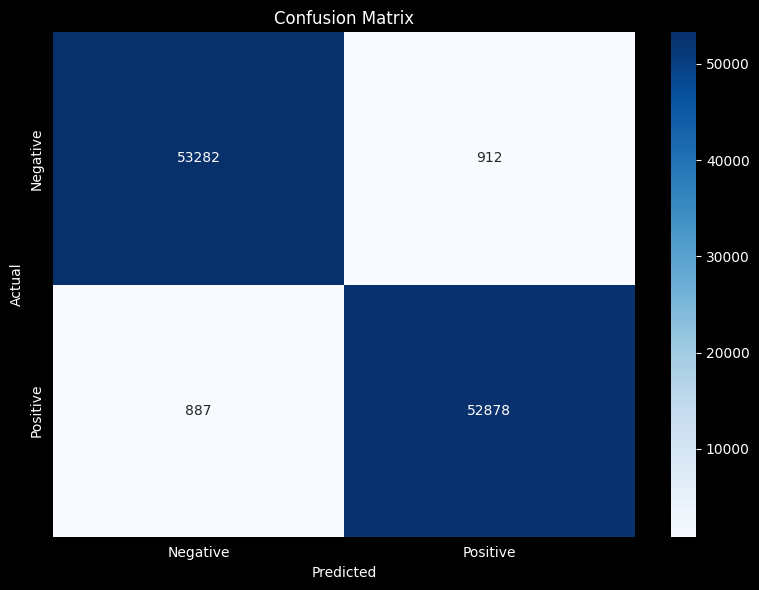

In [ ]:
# disclaimer: block was gen by ai
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Observations

The model looks to have difficulty differentiating between neutral and positive/negative data. Based on our initial analysis in Step 0 of the pipeline, we have combined `Neutral` and `Irrelevant` sentiments together (total: 30893), which creates more data. With more data creates a more error 

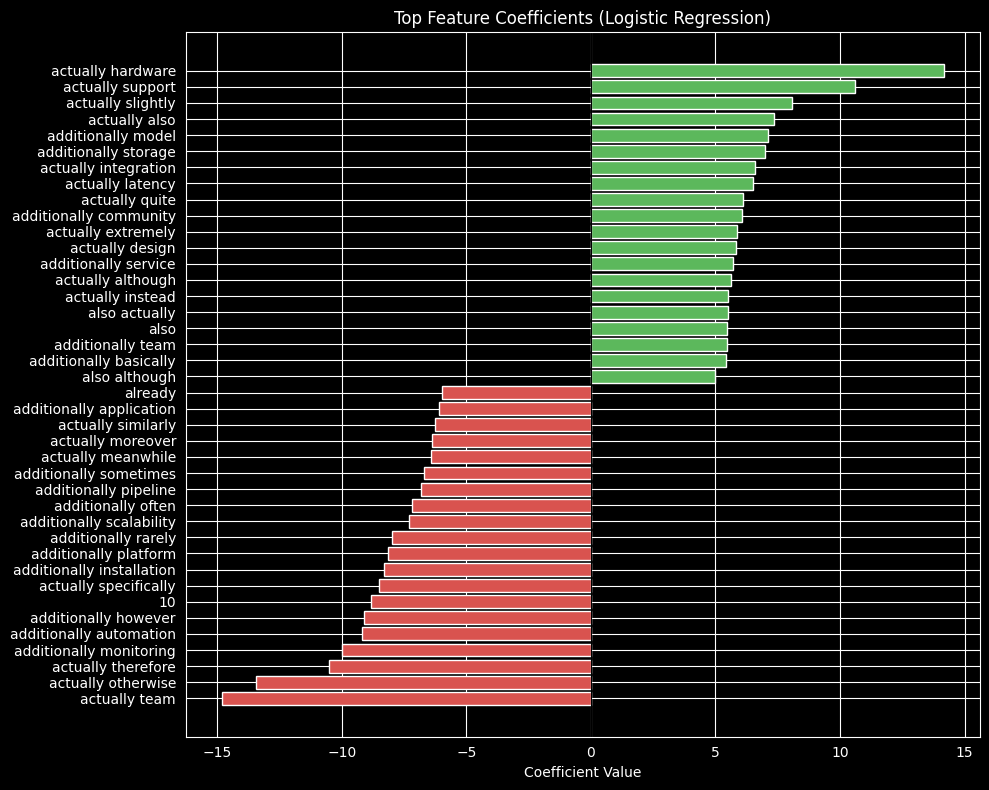

In [ ]:
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

top_n = 20
top_pos_idx = np.argsort(coefficients)[-top_n:]
top_neg_idx = np.argsort(coefficients)[:top_n]
indices = np.concatenate([top_neg_idx, top_pos_idx])
values = coefficients[indices]
labels = feature_names[indices]

colors = ['#d9534f' if v < 0 else '#5cb85c' for v in values]

plt.figure(figsize=(10, 8))
plt.barh(labels, values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top Feature Coefficients (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

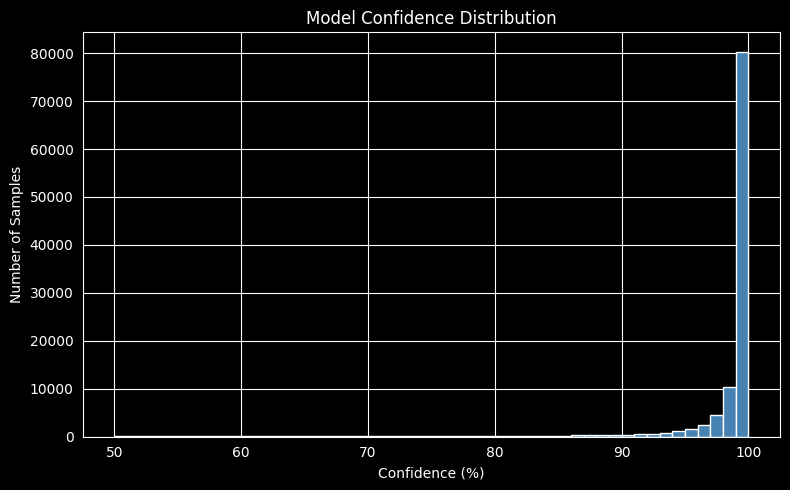

In [ ]:
probs = model.predict_proba(X_test)
confidence = np.max(probs, axis=1) * 100

plt.figure(figsize=(8, 5))
plt.hist(confidence, bins=50, color='steelblue', edgecolor='white')
plt.title('Model Confidence Distribution')
plt.xlabel('Confidence (%)')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()


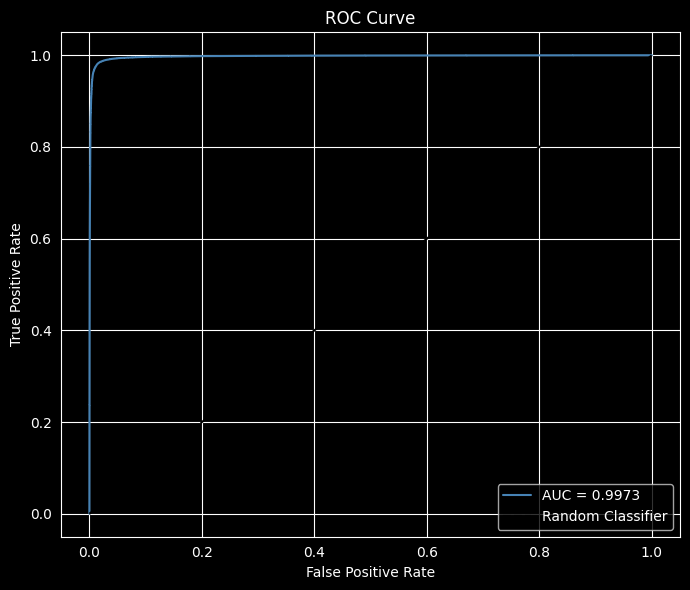

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, probs[:, 1], pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

[98.96348572 99.70987701 99.91306305 99.97111664 99.98483276]


(array([   60.,    71.,    72.,    61.,    54.,    68.,    77.,    64.,
           65.,    64.,    65.,    66.,    74.,    69.,    81.,    57.,
           78.,    76.,    78.,    94.,    98.,   108.,    97.,    88.,
           98.,   122.,   102.,   104.,   123.,   129.,   131.,   159.,
          168.,   158.,   191.,   193.,   236.,   237.,   284.,   338.,
          395.,   472.,   558.,   662.,   835.,  1165.,  1680.,  2538.,
         4629., 10145.]),
 array([50.02828979, 51.00772476, 51.98715591, 52.96659088, 53.94602585,
        54.925457  , 55.90489197, 56.88432312, 57.86375809, 58.84319305,
        59.82262421, 60.80205917, 61.78149414, 62.76092529, 63.74036026,
        64.71979523, 65.69922638, 66.67866516, 67.65809631, 68.63752747,
        69.61695862, 70.5963974 , 71.57582855, 72.5552597 , 73.53469849,
        74.51412964, 75.49356079, 76.47299957, 77.45243073, 78.43186188,
        79.41130066, 80.39073181, 81.37016296, 82.34959412, 83.3290329 ,
        84.30846405, 85.2879028

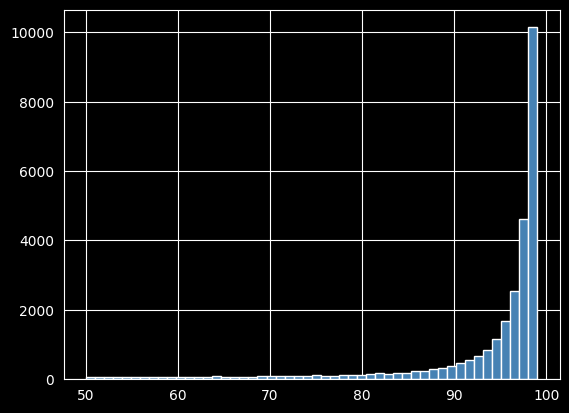

In [ ]:
print(np.percentile(confidence, [25, 50, 75, 90, 95]))
# Zoom into the interesting range
plt.hist(confidence[confidence < 99], bins=50, color='steelblue', edgecolor='white')

# Cost & Loss Metrics

In [ ]:
from sklearn.metrics import log_loss, brier_score_loss, mean_absolute_error

y_prob_pos = probs[:, 1]

log_loss_val   = log_loss(y_test, probs)
brier_val      = brier_score_loss(y_test, y_prob_pos)
mae_val        = mean_absolute_error(y_test, y_prob_pos)
mse_val        = float(np.mean((y_test.values - y_prob_pos) ** 2))

print(f"Log Loss  (cross-entropy): {log_loss_val:.4f}")
print(f"Brier Score         (MSE): {brier_val:.4f}  ← same as MSE below")
print(f"MSE (manual)             : {mse_val:.4f}")
print(f"MAE                      : {mae_val:.4f}")

# Bar chart
metrics = {
    "Log Loss": log_loss_val,
    "MSE (Brier)": brier_val,
    "MAE": mae_val,
}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(metrics.keys(), metrics.values(), color=["#e67e22", "#3498db", "#9b59b6"])
ax.set_title("Cost & Loss Metrics")
ax.set_ylabel("Score (lower is better)")
ax.set_ylim(0, max(metrics.values()) * 1.3)
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()
